# Customer Data Analysis

### The First Step in this Project is to Install or Import all the Libraries needed for this Project

#### These libraries will cover:

* Data manipulation

* Visualization

* Statistical analysis

* Machine learning (clustering)

* Data preprocessing

#### Below is the Code for Importing the Libraries

In [1]:
# ===============================
# CUSTOMER SEGMENTATION PROJECT
# Library Setup
# ===============================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# Machine Learning (Clustering)
from sklearn.cluster import KMeans

# Data Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction (Advanced Analysis)
from sklearn.decomposition import PCA

# Model Evaluation
from sklearn.metrics import silhouette_score

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Plotting Style
sns.set(style="whitegrid")

print("Libraries successfully loaded.")

Libraries successfully loaded.


#### What Each Library Will Be Used For

| Library               | Purpose                       |
| --------------------- | ----------------------------- |
| pandas                | Data loading and manipulation |
| numpy                 | Numerical operations          |
| matplotlib            | Base visualization library    |
| seaborn               | Statistical visualizations    |
| scipy                 | Statistical testing           |
| sklearn.cluster       | K-Means clustering            |
| sklearn.preprocessing | Feature scaling               |
| sklearn.decomposition | PCA dimensionality reduction  |
| sklearn.metrics       | Cluster evaluation            |


#### Just to Track the Version of some of the Libraries Imported

In [2]:
print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("Seaborn Version:", sns.__version__)

Pandas Version: 2.3.3
NumPy Version: 2.3.5
Seaborn Version: 0.13.2


### Next is to Load my Dataset - Filename = Mall_Customers.csv

I am using a CSV file for this Project.  I uploaded the File in the Root Folder where Jupyter Notebook can easily access the file for processing.

#### The Code Below Reads CSV file into the DataFrame (df)

In [4]:
df = pd.read_csv("Mall_Customers.csv")

df.head() #reads the first 5 rows of the dataset

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Next is to Understand my Dataset - *Data Understanding Stage*

#### Dataset Shape

In [6]:
# Display number of rows and columns clearly
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 200
Number of Columns: 5


This tells us that we have 200 Rows and 5 Columns of Dataset.  The dataframe(df).shape has been assigned to variable rows and columns

#### Next, I am using the following commands for more Data Understaning - df.column, df.info(), df.describe() and df.head()

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.columns # To show all the Variables in the Dataset

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
df.isnull().sum() # checking for missing values

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
df.duplicated().sum() # checking for duplicate values

np.int64(0)

In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


The Analysis above has shown that there are no empty rows, or missing values. The Maximum Age is 70, lowest is 18 years.  Highest income 137k and the lowest is 15k.  It also shows the Mean and Standard Deviation of the values.  There are no duplicate values here too.

#### Next, I will be checking the Categorical Variables - in this Case 'Gender'

In [14]:
df['Gender'].unique() # checking the Unique attributes here

array(['Male', 'Female'], dtype=object)

In [15]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

**The above counts the number of Females and Males we have in the Distribution.**

#### So far, the following have been Completed

✔ Dataset loading
✔ Dataset shape
✔ Data preview
✔ Column identification
✔ Data structure inspection
✔ Statistical summary
✔ Missing value detection
✔ Duplicate detection
✔ Category inspection

### Data Cleaning Session

The first thing here - The Column headers will be changes to make coding easy to write.  The Rename command is used here...

In [16]:
# Rename columns for easier analysis
df = df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
})

# Verify the new column names
df.columns

Index(['customer_id', 'gender', 'age', 'annual_income', 'spending_score'], dtype='object')

The Columns headers have been changed to lower case for easier analysis.

Next, I will display the dataset to show the header changes

In [17]:
 # Display first rows to confirm rename
df.head()

,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


---------------
Next, to Reconfirm the Missing Value check

In [18]:
# Check missing values in each column
df.isnull().sum()

customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

--------------------------
Next, For Academic purpose, some steps for handling Missing values, would be highlighed.  This particular dataset has no missing values but the steps and codes below would be a great help for handling missing values in your dataset.

### Handling Missing Values (Only If They Exist)

#### If missing values are found, common treatments include:

**Remove rows with missing values** 
    
df = df.dropna()

**Replace missing values with mean**

df['age'].fillna(df['age'].mean(), inplace=True)

**Replace with median**

df['annual_income'].fillna(df['annual_income'].median(), inplace=True)

Like, mentioned above, for this particular Mall Customers dataset, you will usually find no missing values, so no action is required.

---------------------

### Handling Duplicate Records


*Check number of duplicate rows in the dataset*
    

df.duplicated().sum()
    

*What this does is to remove all the duplicate rows*


df.duplicated() *identifies rows that are exact duplicates.*


.sum() *counts how many duplicate rows exist.*



### Interpretation:


0 → means No duplicate rows exist.
    

Any number greater than 0 means duplicate records are present.
    


*If duplicates exist, you can inspect them using:*


#### Display duplicate rows


df[df.duplicated()]


*This helps you visually confirm which rows are repeated.*


#### If duplicates are detected, remove them with:

*Remove duplicate rows*


df = df.drop_duplicates()


#### Verify Again After Removal


df.duplicated().sum()



#### Why This Step Matters

*Duplicate records can:*

* Bias statistical summaries

* Distort cluster formation

* Misrepresent customer counts

* Cleaning duplicates ensures accurate analysis and modeling.

## Data Cleaning

#### Check and Validate Data Types

In [23]:
# Check data types of each column

df.dtypes

customer_id        int64
gender            object
age                int64
annual_income      int64
spending_score     int64
dtype: object

#### Convert Gender to Category

In [27]:
# Convert gender column to categorical type

df['gender'] = df['gender'].astype('category')

In [28]:
# Verify the Change

df.dtypes

customer_id          int64
gender            category
age                  int64
annual_income        int64
spending_score       int64
dtype: object

### Using category type:

* saves memory

* improves performance

* makes grouping and analysis cleaner

### Exploratory Data Analysis (EDA)

#### First, Univariate Analysis would be done:

Understanding each variable individually.

*We will start with:*

* Distribution of Age
* Distribution of Annual Income
* Distribution of Spending Score
* Gender distribution

------------------

#### Customer Gender Distribution

*Questions to answer here:*

* How many male vs female customers are in the dataset?

* What percentage of customers belong to each gender?

In [29]:
# Count number of customers by gender

df['gender'].value_counts()

gender
Female    112
Male       88
Name: count, dtype: int64

In [30]:
# Percentage distribution of gender

df['gender'].value_counts(normalize=True) * 100

gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64

### Visualizing Gender Distribution (Bar Chart)

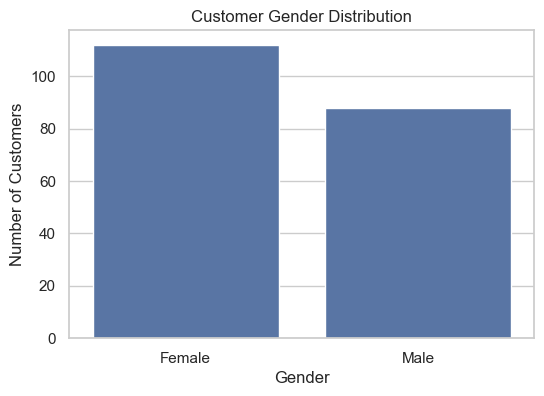

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

#### Pie Chart Report

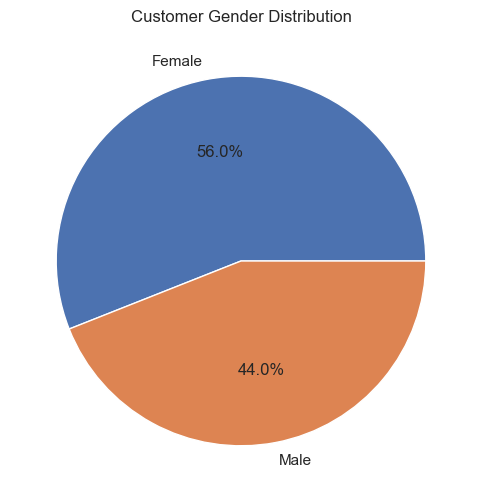

In [32]:
# Pie Chart for clearer view

df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    title='Customer Gender Distribution'
)

plt.ylabel('')
plt.show()

### Insight from the Analysis done:

The dataset shows that female customers represent the majority of mall shoppers, accounting for approximately 56% of customers, while male customers represent about 44%. This suggests that marketing strategies targeting female shoppers may have a significant impact on overall mall revenue.

-------------------

### EDA - Univariate Numerical Analysis

This helps us understand the demographic profile of mall customers.

#### We will analyze the distribution of Age <br>

**This will answer questions such as:** <br><br>

* What is the average customer age?

* What age group dominates the mall?

* Are there younger or older customer concentrations?

----------------------------  
<br>

### Age Distribution Analysis

**Key questions we want to answer:**<br><br>

* What is the average customer age?

* What is the youngest and oldest customer?

* How are customers distributed across age groups?

In [34]:
# Summary statistics for Age

df['age'].describe()

count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: age, dtype: float64

### Age Distribution (Histogram)

This helps visualize how ages are spread across customers.

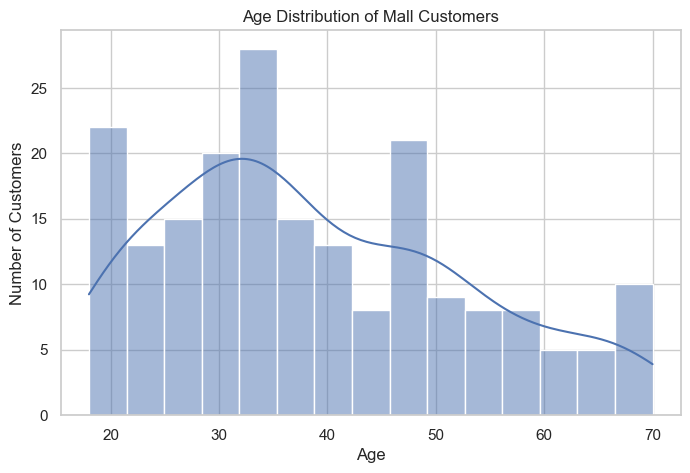

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=15, kde=True)

plt.title('Age Distribution of Mall Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

#### What This Shows

**concentration of age groups**

whether age distribution is skewed or balanced

### Age Distribution (Boxplot)

**Boxplots will help us detect outliers and spread.**

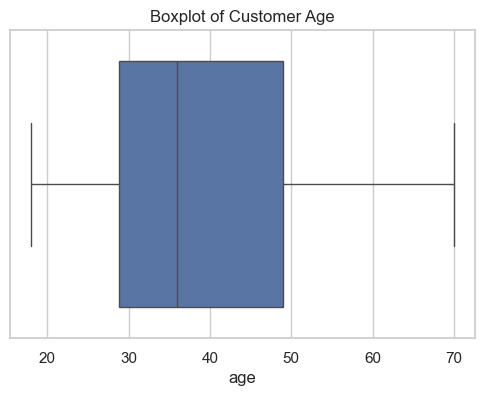

In [36]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['age'])

plt.title('Boxplot of Customer Age')

plt.show()

#### What This Shows

* median age

* spread of age values

* possible age outliers

#### Insight from the BoxPlot Report above

The boxplot analysis shows that the median customer age is approximately 36 years, with the majority of customers falling between 28 and 49 years. The age range spans from 18 to 70 years, indicating that the mall attracts a broad demographic. No significant outliers are present, suggesting that the age data is consistent and well distributed.

### Age Frequency Distribution

**This shows how many customers fall into each age.**



In [38]:
df['age'].value_counts().sort_index()

age
18     4
19     8
20     5
21     5
22     3
23     6
24     4
25     3
26     2
27     6
28     4
29     5
30     7
31     8
32    11
33     3
34     5
35     9
36     6
37     3
38     6
39     3
40     6
41     2
42     2
43     3
44     2
45     3
46     3
47     6
48     5
49     7
50     5
51     2
52     2
53     2
54     4
55     1
56     1
57     2
58     2
59     4
60     3
63     2
64     1
65     2
66     2
67     4
68     3
69     1
70     2
Name: count, dtype: int64

### Annual Income Distribution Analysis

##### Key questions we want to answer:

* What is the average annual income of customers?

* What is the income range?

* Are customers mostly low, middle, or high income?

* Are there outliers in income levels?

----------------------

### Summary Statistics for Annual Income

In [53]:
# Summary statistics for annual income

df['annual_income'].describe().round(2)

count    200.00
mean      60.56
std       26.26
min       15.00
25%       41.50
50%       61.50
75%       78.00
max      137.00
Name: annual_income, dtype: float64

**The unit is thousand dollars (k$).**

**For example:**

60 = $60,000 annual income

### Annual Income Distribution (Histogram)

This shows how customer incomes are distributed.

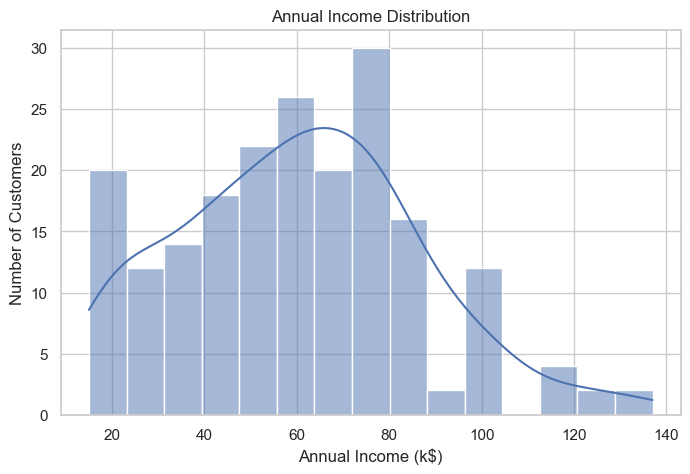

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(df['annual_income'], bins=15, kde=True)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

#### What This Shows

* concentration of income groups

* income patterns among customers

* possible income clusters

### Annual Income Boxplot

**This helps identify spread and outliers.**

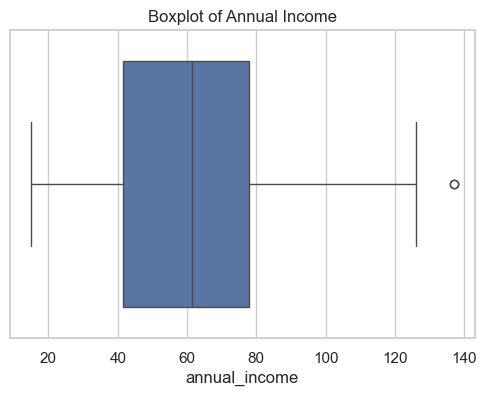

In [55]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['annual_income'])

plt.title('Boxplot of Annual Income')

plt.show()

### Income Frequency Distribution

This shows how many customers fall within each income level.

In [59]:
pd.set_option('display.max_rows', None)
df['annual_income'].value_counts().sort_index()

annual_income
15      2
16      2
17      2
18      2
19      4
20      4
21      2
23      2
24      2
25      2
28      4
29      2
30      2
33      4
34      2
37      2
38      2
39      4
40      4
42      2
43      4
44      2
46      4
47      2
48      6
49      2
50      2
54     12
57      2
58      2
59      2
60      6
61      2
62      6
63      6
64      2
65      4
67      4
69      2
70      2
71      6
72      2
73      4
74      2
75      2
76      2
77      4
78     12
79      2
81      2
85      2
86      2
87      6
88      4
93      2
97      2
98      2
99      2
101     2
103     4
113     2
120     2
126     2
137     2
Name: count, dtype: int64

### Insight from the Analysis

The annual income distribution shows that customer incomes range from approximately 15,000 to 137,000 Dollars, with an average income of about 60,000 Dollars. Most customers fall within the 41,000 to 78,000 Dollars income range, representing the middle 50% of the dataset. This indicates that the mall primarily attracts middle-income customers, although both lower-income and higher-income shoppers are also present.

-------------------

### Spending Score Distribution Analysis <br>

**Key questions we want to answer:**

* What is the average spending score?

* Are most customers low spenders or high spenders?

* Is the spending behavior evenly distributed?

* Are there extreme spending patterns?

### Summary Statistics for Spending Score

In [61]:
# Summary statistics for spending score

df['spending_score'].describe().round(2)

count    200.00
mean      50.20
std       25.82
min        1.00
25%       34.75
50%       50.00
75%       73.00
max       99.00
Name: spending_score, dtype: float64

**Interpretation**

| Statistic | Meaning                 |
| --------- | ----------------------- |
| Mean      | Average spending score  |
| Min       | Lowest spending score   |
| Max       | Highest spending score  |
| 25%       | Lower spending quartile |
| 50%       | Median spending score   |
| 75%       | Upper spending quartile |



* Average spending score ≈ 50

* Spending score ranges between 1 and 99

**This suggests a balanced distribution of spending behavior.**

### Spending Score Distribution (Histogram)

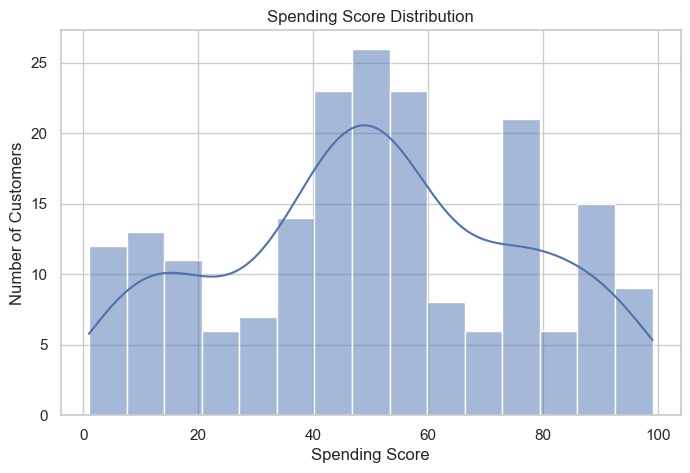

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(df['spending_score'], bins=15, kde=True)

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.show()

#### What This Shows

**The histogram helps reveal:**

* groups of low spenders

* moderate spenders

* high spenders

### Spending Score Boxplot

This helps detect outliers and spread of spending behavior.

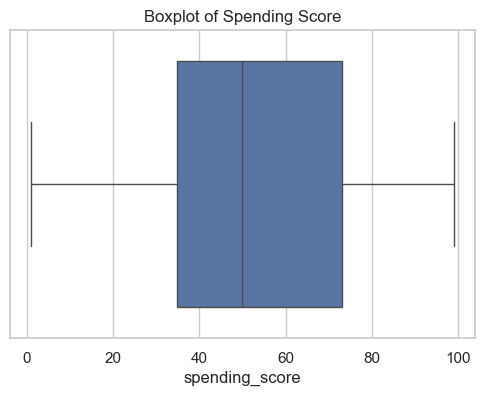

In [63]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['spending_score'])

plt.title('Boxplot of Spending Score')

plt.show()

### Spending Score Frequency Distribution

This shows how many customers fall at each spending score level.

In [64]:
df['spending_score'].value_counts().sort_index()

spending_score
1     2
3     1
4     2
5     4
6     2
7     1
8     1
9     1
10    2
11    1
12    1
13    3
14    4
15    3
16    2
17    3
18    1
20    2
22    1
23    1
24    1
26    2
27    1
28    2
29    2
31    1
32    2
34    1
35    5
36    2
39    2
40    4
41    4
42    8
43    3
44    1
45    1
46    6
47    4
48    5
49    3
50    5
51    3
52    5
53    1
54    3
55    7
56    4
57    2
58    2
59    5
60    3
61    2
63    1
65    1
66    1
68    1
69    2
71    1
72    2
73    6
74    2
75    5
76    2
77    3
78    1
79    2
81    2
82    1
83    2
85    1
86    2
87    2
88    3
89    1
90    2
91    2
92    3
93    2
94    1
95    2
97    2
98    1
99    1
Name: count, dtype: int64

### Insight from Analysis

The spending score distribution ranges from 1 to 99, with an average score of approximately 50, indicating that customers are fairly balanced between low and high spending behavior. The middle 50% of customers have spending scores between approximately 35 and 73, suggesting moderate purchasing behavior among most shoppers.

Also, the boxplot of spending scores does not show any outliers. All values fall within the expected range based on the interquartile range rule. This indicates that customer spending behavior is distributed normally without extreme spending anomalies.

-------------------

## Next is Bivariate Analysis.

Bivariate Analysis is a statistical technique used to analyze the relationship between two variables. The goal is to determine how one variable changes in relation to another variable.

**In simple terms:**

* Bivariate = Two Variables

It examines whether there is an association, pattern, or correlation between two variables in a dataset.

#### Purpose of Bivariate Analysis

Bivariate analysis helps answer questions such as:

* Does income influence spending behavior?

* Do males and females spend differently?

* Does age affect purchasing patterns?

Bivariate will help identify relationships that cannot be seen when looking at variables individually.

-------------------

### Income vs Spending Score Analysis

This is the most critical visualization in the entire Mall Customer project because it reveals customer segments, which later become the basis for K-Means clustering.


#### Objective

To analyze the relationship between:

* Annual Income

* Spending Score

#### This helps answer questions such as:

* Do higher-income customers spend more?

* Are there different types of shoppers?

* Are there groups of customers with similar behavior?

### Scatter Plot Visualization

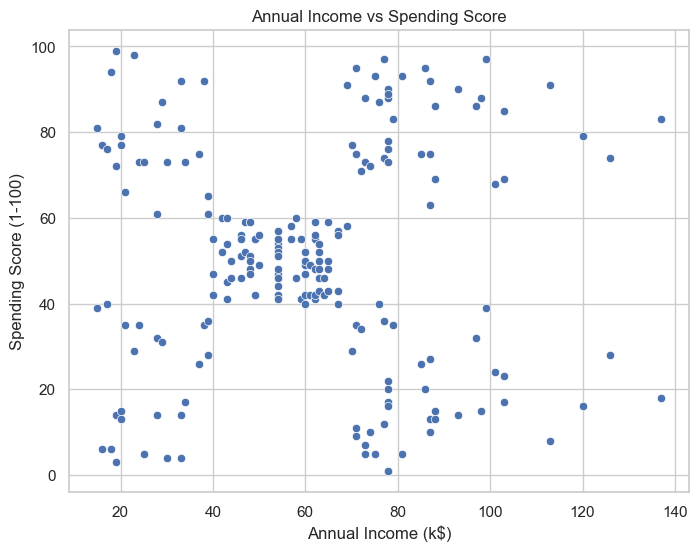

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='annual_income',
    y='spending_score',
    data=df
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

##### What the Scatter Plot Shows

Each point represents a customer.

* X-axis → Annual Income

* Y-axis → Spending Score

The scatter plot helps identify natural patterns or clusters of customers.

Typically, you will notice distinct groups forming, which may include:


| Customer Type                     | Description                   |
| --------------------------------- | ----------------------------- |
| High Income – High Spending       | Premium customers             |
| High Income – Low Spending        | Potential customers to target |
| Low Income – High Spending        | Impulsive shoppers            |
| Low Income – Low Spending         | Budget customers              |
| Average Income – Average Spending | Regular customers             |


### Color by Gender (More Insight)

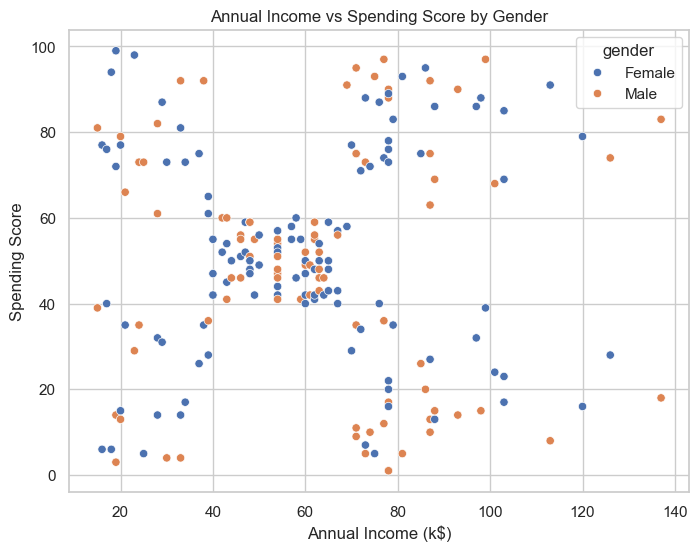

In [66]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='annual_income',
    y='spending_score',
    hue='gender',
    data=df
)

plt.title('Annual Income vs Spending Score by Gender')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')

plt.show()

## The Analysis insight

The scatter plot of annual income versus spending score reveals several distinct customer patterns. Some customers with high income also exhibit high spending behavior, representing premium customers. Others have high income but low spending scores, suggesting potential customers that the mall could target with marketing strategies. Additionally, there are customers with lower incomes but high spending behavior, indicating highly engaged shoppers.

#### Why This Step Is Important

This visualization is important because it reveals natural groupings of customers, which later become the basis for K-Means clustering in customer segmentation.

-------------------------------

### Quantify the relationship between annual_income and spending_score

Pearson correlation: 0.01 (p-value: 0.889)


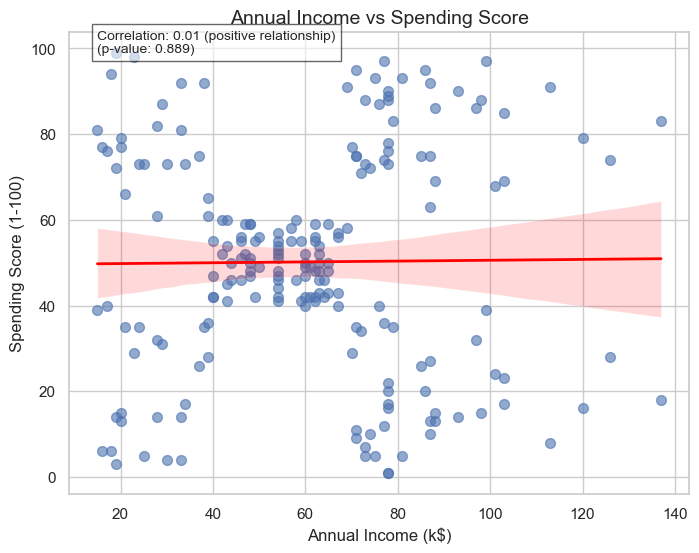

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Calculate Pearson correlation
corr, p_value = pearsonr(df['annual_income'], df['spending_score'])
print(f"Pearson correlation: {corr:.2f} (p-value: {p_value:.3f})")

# Plot scatter plot with regression line
plt.figure(figsize=(8,6))
sns.regplot(
    x='annual_income',
    y='spending_score',
    data=df,
    scatter_kws={'s':50, 'alpha':0.6},  # point size and transparency
    line_kws={'color':'red', 'lw':2}    # regression line
)

# Add title and labels
plt.title('Annual Income vs Spending Score', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

# Add text box with correlation explanation
if corr > 0:
    relation = "positive"
elif corr < 0:
    relation = "negative"
else:
    relation = "no"

plt.text(
    x=df['annual_income'].min(), 
    y=df['spending_score'].max(), 
    s=f"Correlation: {corr:.2f} ({relation} relationship)\n(p-value: {p_value:.3f})",
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='black')
)

plt.show()

### What this does:

Pearson correlation (corr) measures the strength and direction of the linear relationship between annual_income and spending_score.

+1 → perfect positive correlation

0 → no linear correlation

-1 → perfect negative correlation

sns.regplot adds a best-fit line to your scatter plot, making it easy to see the trend.

The correlation value is shown in the title for quick interpretation.

#### The p-value here is 0.889, which means the relationship is close to +1 (perfect positive correlation).


------------------------------------

### Age vs Spending Score Analysis

<br>**The Basic Relationship Questions to Answer here:**

* Is there a relationship between age and spending score?

* Does spending score increase or decrease with age, or is it random?

### Visual Analysis — Scatter Plot

A scatter plot is ideal to see any correlation or clustering pattern.

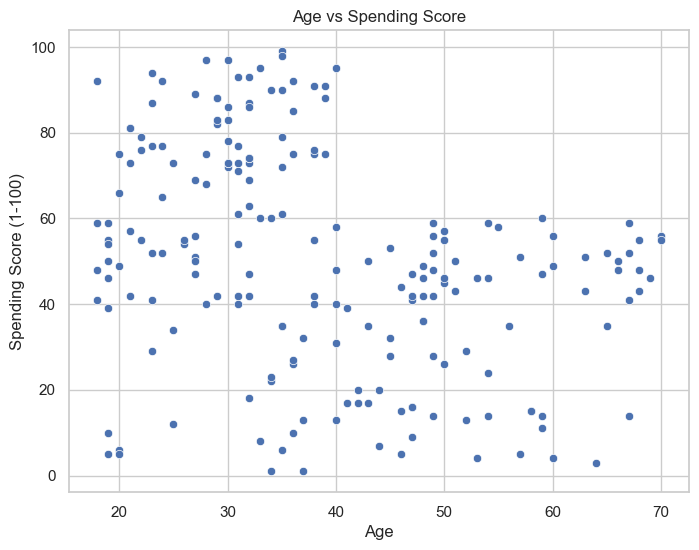

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='age',
    y='spending_score',
    data=df
)
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

#### Interpretation:

* Look for trends: Does spending score decrease or increase with age? Or is it random?

* Look for clusters: Are there groups of customers with similar ages but varying spending behavior?

* Identify outliers: Extremely high or low spending scores in certain age groups.

### Correlation Analysis

In [71]:
correlation = df['age'].corr(df['spending_score'])
print(f"Correlation between Age and Spending Score: {correlation:.2f}")

Correlation between Age and Spending Score: -0.33


#### Interpretation of correlation coefficient:

* Close to +1: Older customers tend to spend more.

* Close to -1: Older customers tend to spend less.

* Around 0: Age doesn’t strongly affect spending behavior.

#### Correlation between Age and Spending Score is  -0.33

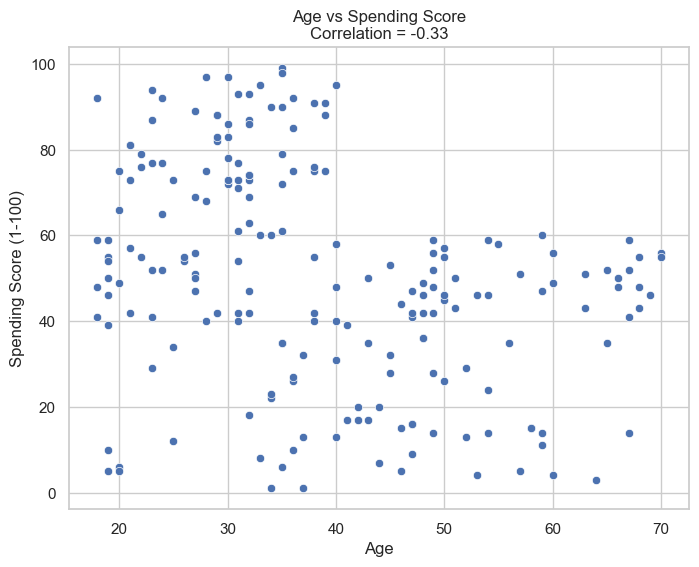

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='spending_score', data=df)
plt.title(f'Age vs Spending Score\nCorrelation = {correlation:.2f}')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

### Regression Line

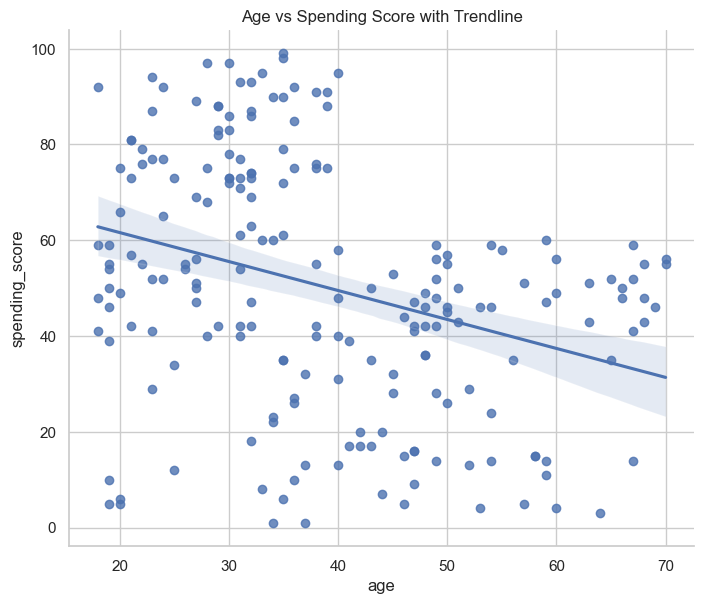

In [72]:
sns.lmplot(x='age', y='spending_score', data=df, height=6, aspect=1.2)
plt.title('Age vs Spending Score with Trendline')
plt.show()

#### Observation:

The regression line will show if there’s a positive or negative relationship or no relationship at all.

#### Why this Insight is important:
    
* Understanding how age relates to spending score helps in customer segmentation. For example:

* Younger customers may have high spending scores (more impulsive spending).

* Older customers may have lower spending scores (more stable, predictable behavior).

In [75]:
df[['age', 'spending_score']].describe()

,age,spending_score
count,200.000000,200.000000
mean,38.850000,50.200000
std,13.969007,25.823522
min,18.000000,1.000000
25%,28.750000,34.750000
50%,36.000000,50.000000
75%,49.000000,73.000000
max,70.000000,99.000000


## Customer Segmentation / Clustering Preparation

#### The task to perform here includes:

**1. Select Features for Clustering**

*Variables to be used that define customer behaviour:*

* annual_income

* spending_score

* Optionally age (depending on our business goal)

*To decide whether to scale/normalize these features.*

**2. Data Preprocessing**

* Handle missing values (if any) in selected features.

* Standardize or normalize numeric features:

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['age', 'annual_income', 'spending_score']])

* Need to check for outliers that may affect clustering.

**3. Choose Clustering Method**

*Common methods for customer segmentation:*

* K-Means Clustering

* Hierarchical Clustering

* DBSCAN (for non-linear clusters)

**4. Determine Optimal Number of Clusters**

*For K-Means, we use Elbow Method:*

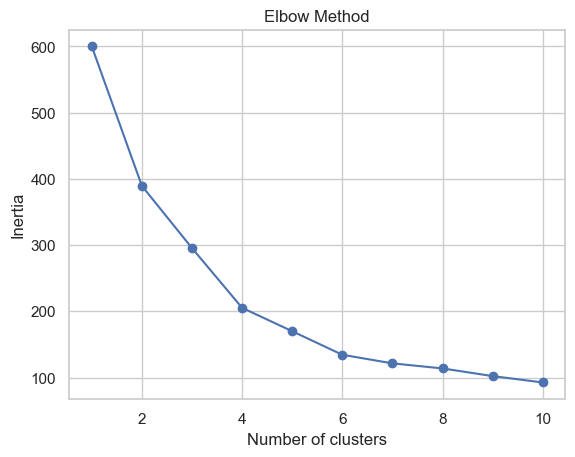

In [78]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### Next, We will take the EDA outputs (age, annual income, spending score) and performs K-Means clustering with cluster profiling.

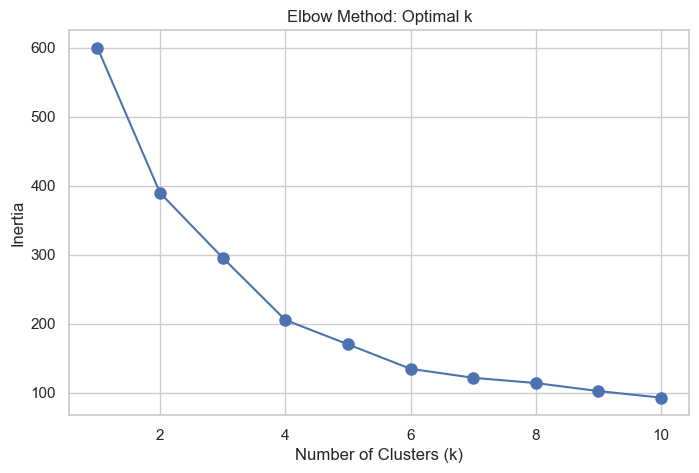

Cluster Profiling:
           age  annual_income  spending_score  Size
Cluster                                            
0        55.28          47.62           41.71    58
1        32.88          86.10           81.53    40
2        25.77          26.12           74.85    26
3        26.73          54.31           40.91    45
4        44.39          89.77           18.48    31


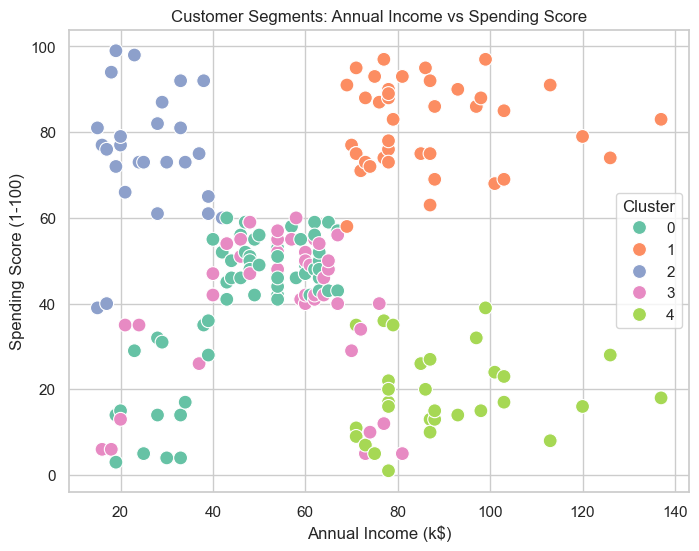

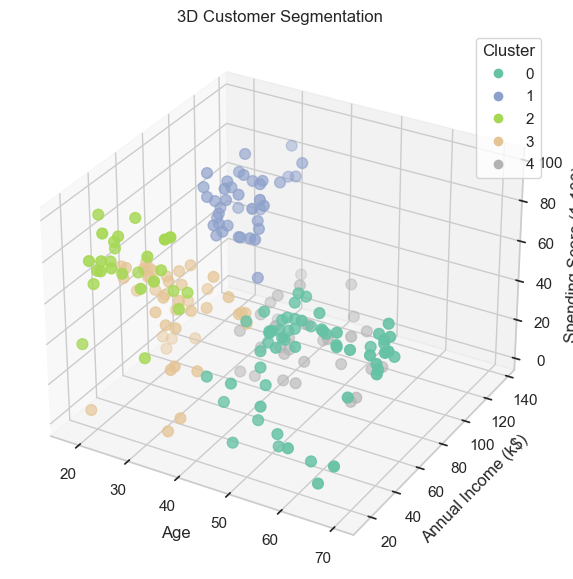

In [80]:
# Customer Segmentation using K-Means Clustering

# 1️. Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 2️. Select features for clustering
features = ['age', 'annual_income', 'spending_score']
X = df[features]

# 3️. Data Preprocessing: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4️. Determine the optimal number of clusters using Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Optimal k')
plt.show()

# 5️. From the Elbow plot, choose the optimal k (example: k=5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 6️. Cluster Profiling: Calculate average values per cluster
cluster_profile = df.groupby('Cluster')[features].mean().round(2)
cluster_size = df['Cluster'].value_counts().sort_index()
cluster_profile['Size'] = cluster_size
print("Cluster Profiling:")
print(cluster_profile)

# 7️. Visualize clusters (Annual Income vs Spending Score)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='annual_income', 
    y='spending_score', 
    hue='Cluster', 
    palette='Set2', 
    data=df,
    s=100
)
plt.title('Customer Segments: Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

# Optional: 3D Visualization with Age
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df['age'], df['annual_income'], df['spending_score'], 
    c=df['Cluster'], cmap='Set2', s=60
)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('3D Customer Segmentation')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

### What this workflow has done is:

1. Standardizes age, annual_income, and spending_score.

2. Uses the Elbow Method to find the optimal number of clusters.

3. Performs K-Means clustering.

4. Adds the cluster label to my dataframe.

5. Provides cluster profiling with average metrics and cluster size.

6. Visualizes clusters in 2D (Income vs Spending Score) and 3D (including Age).

   age  annual_income  spending_score  Cluster              Cluster_Label
0   19             15              39        2  Low Income - High Spender
1   21             15              81        2  Low Income - High Spender
2   20             16               6        3   Low Income - Low Spender
3   23             16              77        2  Low Income - High Spender
4   31             17              40        2  Low Income - High Spender


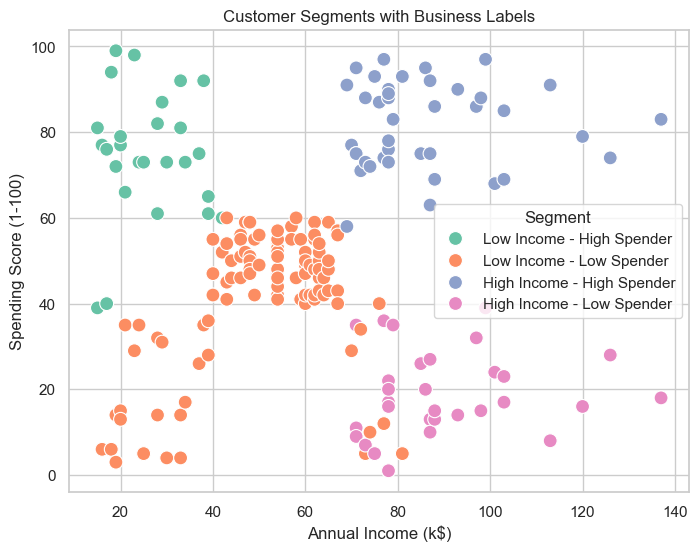

In [81]:
# Assign Business-Friendly Labels to Clusters

# Define a function to label clusters based on profile
def label_cluster(row):
    age = row['age']
    income = row['annual_income']
    score = row['spending_score']
    
    if income >= 70 and score >= 70:
        return 'High Income - High Spender'
    elif income >= 70 and score < 70:
        return 'High Income - Low Spender'
    elif income < 70 and score >= 70:
        return 'Low Income - High Spender'
    elif income < 70 and score < 70:
        return 'Low Income - Low Spender'
    else:
        return 'Medium Segment'

# Apply the function to cluster centroids for labeling
cluster_centroids = df.groupby('Cluster')[['age','annual_income','spending_score']].mean().round(2)

# Create a dictionary to map cluster number → label
cluster_labels = {}
for cluster in cluster_centroids.index:
    cluster_labels[cluster] = label_cluster(cluster_centroids.loc[cluster])

# Map cluster labels to original dataframe
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

# Check the first few rows
print(df[['age','annual_income','spending_score','Cluster','Cluster_Label']].head())

# Optional: Visualize with labels in 2D
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='annual_income', 
    y='spending_score', 
    hue='Cluster_Label', 
    palette='Set2', 
    data=df,
    s=100
)
plt.title('Customer Segments with Business Labels')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Segment')
plt.show()

### Simple Interpretation of the Workflow Outputs

#### After running the workflow:

##### Clusters Identified:

* Each customer is assigned to a cluster based on age, annual_income, and spending_score.

* Clusters group customers with similar behavior and demographics.


#### Cluster Labels:

##### Clusters are now business-friendly:

* High Income – High Spender: Older or younger customers with high purchasing power and high spending score.

* High Income – Low Spender: Customers with high income but conservative spending.

* Low Income – High Spender: Customers with lower income but spend a lot relative to their income.

* Low Income – Low Spender: Customers with lower income and low spending behavior.


#### Insights:

* Identify target groups for marketing and promotions.

* Recognize which segments are profitable or require engagement strategies.

* Understand patterns like: younger people may cluster as high spenders, while older high-income customers may be conservative spenders.

### Summary Table

In [83]:
# Summary Table

# Calculate cluster size
cluster_size = df.groupby('Cluster_Label').size().rename('Size')

# Calculate average Age, Income, Spending Score per segment
cluster_means = df.groupby('Cluster_Label')[['age','annual_income','spending_score']].mean().round(2)

# Combine into one summary table
summary_table = pd.concat([cluster_means, cluster_size], axis=1).reset_index()
summary_table.rename(columns={'Cluster_Label':'Segment'}, inplace=True)

print("Customer Segmentation Summary:")
print(summary_table)

Customer Segmentation Summary:
                      Segment    age  annual_income  spending_score  Size
0  High Income - High Spender  32.88          86.10           81.53    40
1   High Income - Low Spender  44.39          89.77           18.48    31
2   Low Income - High Spender  25.77          26.12           74.85    26
3    Low Income - Low Spender  42.81          50.54           41.36   103




<br>**CUSTOMER SEGMENTATION SUMMARY TABLE**

| Segment                    | age  | annual_income | spending_score | Size |
| -------------------------- | ---- | ------------- | -------------- | ---- |
| High Income – High Spender | 32.88| 86.10         | 81.53          | 40   |
| High Income – Low Spender  | 44.39| 89.77         | 18.48          | 31   |
| Low Income – High Spender  | 25.77| 26.12         | 74.85          | 26   |
| Low Income – Low Spender   | 42.81| 50.54         | 41.36          | 103  |


### Applications of This Customer Segmentation <br>

**1. Marketing Campaigns:**

* Target high spenders with premium offers.

* Design budget-friendly campaigns for low spenders.

**2. Customer Engagement:**

Personalize communication per segment (e.g., loyalty programs for High Income – Low Spender to encourage more spending).

**3. Strategic Planning:**

* Allocate resources efficiently to segments with highest ROI potential.

* Identify untapped potential (e.g., Low Income – High Spenders may respond well to installment-based promotions).

**4. Sales Forecasting & Promotions:**

Use segment insights to predict sales trends by customer type.